In [1]:
import os, math, random, gc, sys
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torch.serialization
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models, datasets
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    cohen_kappa_score, confusion_matrix, classification_report
)

torch.serialization.add_safe_globals([np._core.multiarray.scalar])

In [2]:
DATASET_DIR  = '/kaggle/input/datasets/tommyngx/kneeoa'
TRAIN_DIR    = f'{DATASET_DIR}/train'
VAL_DIR      = f'{DATASET_DIR}/val'
TEST_DIR     = f'{DATASET_DIR}/test'

device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP      = torch.cuda.is_available()
CLASS_NAMES  = ['Grade 0 (Healthy)', 'Grade 1 (Doubtful)',
                'Grade 2 (Minimal)',  'Grade 3 (Moderate)', 'Grade 4 (Severe)']
NUM_CLASSES  = len(CLASS_NAMES)

BATCH_SIZE   = 64
NUM_EPOCHS   = 100
SEEDS        = [33, 81, 5]
CKPT_DIR     = '/kaggle/working/'
os.makedirs(CKPT_DIR, exist_ok=True)

T_LR           = 1e-3
T_WEIGHT_DECAY = 1e-4

KD_TEMPERATURE = 2.636
KD_ALPHA       = 0.381
S_LR           = 1e-3
S_WEIGHT_DECAY = 1e-4
CONF_SHARPNESS = 0.670

print(f"Device : {device}")
print(f"AMP    : {USE_AMP}")

Device : cuda
AMP    : True


In [3]:
def set_seed(seed=33):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [4]:
def save_resume_ckpt(path, epoch, model, optimizer, scheduler, scaler,
                     history, best_qwk, best_preds, best_labels):
    torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict(),
                'scaler':    scaler.state_dict() if scaler else {},
                'history': history, 'best_qwk': best_qwk,
                'best_preds': best_preds, 'best_labels': best_labels}, path)


def load_resume_ckpt(path, model, optimizer, scheduler, scaler):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    if scaler and ckpt.get('scaler'):
        scaler.load_state_dict(ckpt['scaler'])
    print(f"  ↺ Resumed from epoch {ckpt['epoch']+1}  "
          f"(best QWK so far: {ckpt['best_qwk']:.4f})")
    return (ckpt['epoch'] + 1, ckpt['history'],
            ckpt['best_qwk'], ckpt['best_preds'], ckpt['best_labels'])


def save_best_weights(path, epoch, model, qwk):
    torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                'qwk': qwk}, path)

In [5]:
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0), ratio=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.3),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08), value='random'),
    transforms.Normalize(_MEAN, _STD),
])
val_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_tfm)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_tfm)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_tfm)

train_labels   = [label for _, label in train_dataset.samples]
class_counts   = np.bincount(train_labels, minlength=NUM_CLASSES)
sample_weights = np.array([1.0 / class_counts[lbl] for lbl in train_labels])
sampler = WeightedRandomSampler(
    torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=4, pin_memory=True)

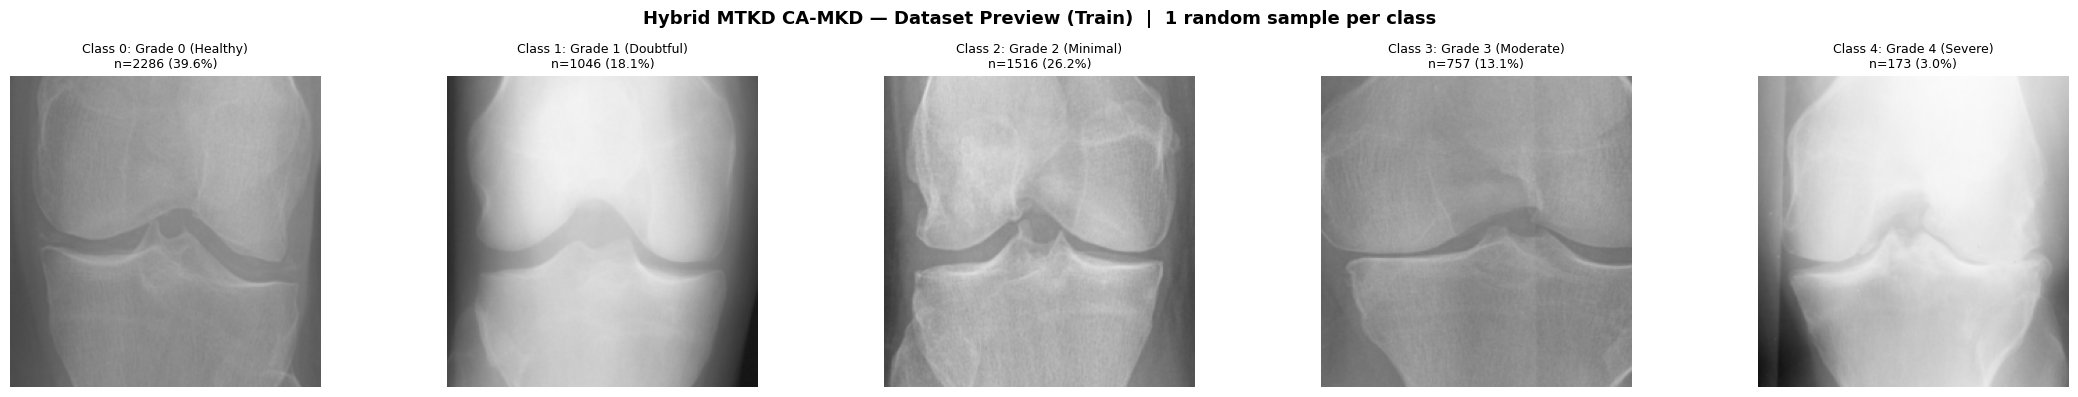


── Dataset Statistics ──────────────────────────────────
  Train: 5778 | Val: 826 | Test: 1656
  Class distribution (train):
  [0] Grade 0 (Healthy)        : 2286 ( 39.6%)  ███████████
  [1] Grade 1 (Doubtful)       : 1046 ( 18.1%)  █████
  [2] Grade 2 (Minimal)        : 1516 ( 26.2%)  ███████
  [3] Grade 3 (Moderate)       :  757 ( 13.1%)  ███
  [4] Grade 4 (Severe)         :  173 (  3.0%)  


In [6]:
def preview_dataset(dataset, split_name="Train"):
    from collections import defaultdict
    img_by_class = defaultdict(list)
    for img_path, label in dataset.samples:
        img_by_class[label].append(img_path)

    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(22, 4))
    fig.suptitle(
        f"Hybrid MTKD CA-MKD — Dataset Preview ({split_name})  |  1 random sample per class",
        fontsize=13, fontweight='bold',
    )
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        paths = img_by_class[cls_idx]
        img   = Image.open(random.choice(paths)).convert('RGB')
        axes[cls_idx].imshow(img)
        axes[cls_idx].set_title(
            f"Class {cls_idx}: {cls_name}\n"
            f"n={len(paths)} ({100*len(paths)/len(dataset):.1f}%)",
            fontsize=9,
        )
        axes[cls_idx].axis('off')
    plt.tight_layout()
    plt.savefig(f'{CKPT_DIR}/dataset_preview.png', dpi=120, bbox_inches='tight')
    plt.show()

    print("\n── Dataset Statistics ──────────────────────────────────")
    print(f"  Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
    print("  Class distribution (train):")
    for i, name in enumerate(CLASS_NAMES):
        n   = class_counts[i]
        bar = '█' * int(30 * n / len(train_dataset))
        print(f"  [{i}] {name:<25s}: {n:4d} ({100*n/len(train_dataset):5.1f}%)  {bar}")

preview_dataset(train_dataset, "Train")

In [7]:
class CoralHead(nn.Module):
    """K-1 shared-weight binary ordinal head (Cao et al., 2019)."""
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc   = nn.Linear(in_features, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(num_classes - 1))

    def forward(self, x):
        return self.fc(x) + self.bias   # (B, K-1)


def coral_loss(logits, labels, num_classes=NUM_CLASSES):
    targets = torch.zeros(labels.size(0), num_classes - 1, device=labels.device)
    for k in range(num_classes - 1):
        targets[:, k] = (labels > k).float()
    return F.binary_cross_entropy_with_logits(logits, targets)


def coral_predict(logits):
    return (torch.sigmoid(logits) > 0.5).sum(dim=1).long()


def coral_logits_to_probs(logits):
    """
    Convert CORAL K-1 cumulative logits to a normalised K-class probability vector.

    P(Y > k) = sigmoid(logits[:, k])
    p(Y = k) = P(Y > k-1) - P(Y > k)
    with P(Y > -1) = 1  and  P(Y > K-1) = 0.

    Returns (B, K) tensor on the probability simplex.
    Ref: Cao et al. (2019), arXiv:1901.07884, eqs. (1)-(3).
    """
    B = logits.size(0)
    cum        = torch.sigmoid(logits)                        # (B, K-1)
    ones       = torch.ones (B, 1, device=logits.device)
    zeros      = torch.zeros(B, 1, device=logits.device)
    cum_padded = torch.cat([ones, cum, zeros], dim=1)         # (B, K+1)
    probs      = cum_padded[:, :-1] - cum_padded[:, 1:]       # (B, K)
    probs      = probs.clamp(min=1e-8)
    return probs / probs.sum(dim=1, keepdim=True)

In [8]:
def get_resnet50_ce_teacher():
    m    = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

def fwd_resnet_ce(model, imgs):
    return model(imgs)

def get_efficientnet_b3_coral_teacher():
    m = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    in_features      = m.classifier[-1].in_features
    m.classifier[-1] = nn.Identity()
    m.coral_head     = CoralHead(in_features, NUM_CLASSES)
    return m

def fwd_efficientnet_coral(model, imgs):
    feat = model.features(imgs)
    feat = model.avgpool(feat).flatten(1)
    feat = model.classifier(feat)
    return model.coral_head(feat)

def get_mobilenet_student():
    m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, NUM_CLASSES)
    return m

def fwd_student(model, imgs):
    return model(imgs)

In [9]:
def _eval_loop(model, loader, pred_fn):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            preds_all.extend(pred_fn(model, imgs.to(device)).cpu().numpy())
            labels_all.extend(labels.numpy())
    return np.array(preds_all), np.array(labels_all)


def evaluate_val_ce(model, loader):
    p, y = _eval_loop(model, loader,
                      lambda m, x: m(x).argmax(dim=1))
    return (float(cohen_kappa_score(y, p, weights='quadratic')),
            float(np.mean(y == p)),
            float(np.mean(np.abs(y - p))),
            float(np.sqrt(np.mean((y - p) ** 2))),
            p.tolist(), y.tolist())


def evaluate_val_coral(model, fwd_fn, loader):
    p, y = _eval_loop(model, loader,
                      lambda m, x: coral_predict(fwd_fn(m, x)))
    return (float(cohen_kappa_score(y, p, weights='quadratic')),
            float(np.mean(y == p)),
            float(np.mean(np.abs(y - p))),
            float(np.sqrt(np.mean((y - p) ** 2))),
            p.tolist(), y.tolist())


def evaluate_on_test(model, loader):
    p, y = _eval_loop(model, loader,
                      lambda m, x: m(x).argmax(dim=1))
    return {'qwk':    float(cohen_kappa_score(y, p, weights='quadratic')),
            'acc':    float(np.mean(y == p)),
            'mae':    float(np.mean(np.abs(y - p))),
            'rmse':   float(np.sqrt(np.mean((y - p) ** 2))),
            'preds':  p.tolist(), 'labels': y.tolist()}

In [10]:
def train_teacher(model, fwd_fn, loss_fn, eval_fn, name, save_path, seed=33):
    resume_path = save_path.replace('.pth', '_resume.pth')
    set_seed(seed)
    model  = model.to(device)
    opt    = optim.AdamW(model.parameters(), lr=T_LR, weight_decay=T_WEIGHT_DECAY)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    history     = {'train_loss': [], 'val_qwk': [], 'val_acc': [],
                   'val_mae': [], 'val_rmse': []}
    best_qwk    = -1.0
    best_preds, best_labels = [], []
    start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = load_resume_ckpt(resume_path, model, opt, sched, scaler)
        history.setdefault('val_mae',  [None] * len(history['val_qwk']))
        history.setdefault('val_rmse', [None] * len(history['val_qwk']))

    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            opt.zero_grad()
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    loss = loss_fn(fwd_fn(model, imgs), labels)
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            else:
                loss = loss_fn(fwd_fn(model, imgs), labels)
                loss.backward(); opt.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        sched.step()

        qwk, acc, mae, rmse, vp, vl = eval_fn(model, val_loader)
        history['val_qwk'].append(qwk); history['val_acc'].append(acc)
        history['val_mae'].append(mae); history['val_rmse'].append(rmse)

        print(f"  Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | "
              f"Acc: {acc*100:.2f}% | QWK: {qwk:.4f} | "
              f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")
        sys.stdout.flush()

        if qwk > best_qwk:
            best_qwk = qwk
            best_preds, best_labels = list(vp), list(vl)
            save_best_weights(save_path, epoch + 1, model, best_qwk)
        save_resume_ckpt(resume_path, epoch, model, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    model.load_state_dict(
        torch.load(save_path, map_location=device,
                   weights_only=False)['model_state_dict'])
    model.eval()
    print(f"\n  {name} best val QWK: {best_qwk:.4f}\n")
    return model

In [11]:
def ca_mkd_loss(s_logits, t_ce_logits, t_coral_logits, labels,
                alpha=KD_ALPHA, temperature=KD_TEMPERATURE,
                conf_sharpness=CONF_SHARPNESS):

    # ── Soft targets at temperature T ──────────────────────────────────────
    p_ce        = F.softmax(t_ce_logits / temperature, dim=1)
    p_coral_raw = coral_logits_to_probs(t_coral_logits)
    p_coral     = F.softmax(torch.log(p_coral_raw.clamp(min=1e-8)) / temperature, dim=1)

    # ── Confidence at T=1 (raw, unflattened signal) ────────────────────────
    p_ce_1    = F.softmax(t_ce_logits, dim=1)
    p_coral_1 = p_coral_raw
    y_oh      = F.one_hot(labels, NUM_CLASSES).float()
    conf_ce    = (y_oh * p_ce_1).sum(dim=1).clamp(min=1e-8) ** conf_sharpness
    conf_coral = (y_oh * p_coral_1).sum(dim=1).clamp(min=1e-8) ** conf_sharpness

    # ── Confidence-weighted aggregate ──────────────────────────────────────
    denom  = conf_ce + conf_coral + 1e-8
    w_ce   = conf_ce   / denom
    w_coral = conf_coral / denom
    p_agg  = w_ce.unsqueeze(1) * p_ce + w_coral.unsqueeze(1) * p_coral

    # ── T²-scaled KL divergence + hard CE ──────────────────────────────────
    s_log = F.log_softmax(s_logits / temperature, dim=1)
    kl    = ((p_agg * (p_agg.log() - s_log)).sum(dim=1) * temperature ** 2).clamp(max=10.0)

    return (1.0 - alpha) * F.cross_entropy(s_logits, labels) + alpha * kl.mean()

In [12]:
def train_student(student, seed, t_ce_model, t_coral_model):
    best_path   = f'{CKPT_DIR}/hybrid_camkd_seed{seed}_best.pth'
    resume_path = f'{CKPT_DIR}/hybrid_camkd_seed{seed}_resume.pth'

    student     = student.to(device)
    t_ce_ref    = t_ce_model.to(device).eval()
    t_coral_ref = t_coral_model.to(device).eval()
    for p in list(t_ce_ref.parameters()) + list(t_coral_ref.parameters()):
        p.requires_grad_(False)

    opt    = optim.AdamW(student.parameters(), lr=S_LR, weight_decay=S_WEIGHT_DECAY)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    history     = {'train_loss': [], 'val_qwk': [], 'val_acc': [],
                   'val_mae': [], 'val_rmse': []}
    best_qwk    = -1.0
    best_preds, best_labels = [], []
    start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = \
            load_resume_ckpt(resume_path, student, opt, sched, scaler)
        history.setdefault('val_mae',  [None] * len(history['val_qwk']))
        history.setdefault('val_rmse', [None] * len(history['val_qwk']))

    for epoch in range(start_epoch, NUM_EPOCHS):
        student.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            opt.zero_grad()
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    s_logits       = fwd_student(student, imgs)
                    t_ce_logits    = fwd_resnet_ce(t_ce_ref, imgs).detach()
                    t_coral_logits = fwd_efficientnet_coral(t_coral_ref, imgs).detach()
                    loss = ca_mkd_loss(s_logits, t_ce_logits, t_coral_logits,
                                       labels, alpha=KD_ALPHA, temperature=KD_TEMPERATURE)
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            else:
                s_logits       = fwd_student(student, imgs)
                t_ce_logits    = fwd_resnet_ce(t_ce_ref, imgs).detach()
                t_coral_logits = fwd_efficientnet_coral(t_coral_ref, imgs).detach()
                loss = ca_mkd_loss(s_logits, t_ce_logits, t_coral_logits,
                                   labels, alpha=KD_ALPHA, temperature=KD_TEMPERATURE)
                loss.backward(); opt.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        sched.step()

        qwk, acc, mae, rmse, vp, vl = evaluate_val_ce(student, val_loader)
        history['val_qwk'].append(qwk); history['val_acc'].append(acc)
        history['val_mae'].append(mae); history['val_rmse'].append(rmse)

        print(f"  Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | "
              f"Acc: {acc*100:.2f}% | QWK: {qwk:.4f} | "
              f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")
        sys.stdout.flush()

        if qwk > best_qwk:
            best_qwk = qwk
            best_preds, best_labels = list(vp), list(vl)
            save_best_weights(best_path, epoch + 1, student, best_qwk)
        save_resume_ckpt(resume_path, epoch, student, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    student.load_state_dict(
        torch.load(best_path, map_location=device,
                   weights_only=False)['model_state_dict'])
    student.eval()
    return {'qwk': best_qwk, 'history': history,
            'preds': best_preds, 'labels': best_labels,
            'seed': seed, 'model': student}

In [13]:
def analyse_results(results_list, scenario_title,
                    loss_label="Loss", test_results_list=None):
    import matplotlib.ticker as mticker

    seeds       = [r['seed'] for r in results_list]
    all_losses  = np.array([r['history']['train_loss'] for r in results_list])
    all_qwks    = np.array([r['history']['val_qwk']    for r in results_list])
    all_accs    = np.array([r['history']['val_acc']    for r in results_list])
    all_maes    = np.array([r['history']['val_mae']    for r in results_list], dtype=float)
    epochs      = np.arange(1, all_losses.shape[1] + 1)
    best_res    = max(results_list, key=lambda x: x['qwk'])
    colors      = plt.cm.tab10.colors

    cms         = [confusion_matrix(r['labels'], r['preds'], labels=list(range(NUM_CLASSES)))
                   for r in results_list]
    cm_avg      = np.mean(cms, axis=0)
    cm_std      = np.std(cms,  axis=0)
    cm_avg_norm = cm_avg / cm_avg.sum(axis=1, keepdims=True)
    cm_best     = confusion_matrix(best_res['labels'], best_res['preds'],
                                   labels=list(range(NUM_CLASSES)))

    seed_accs   = [np.mean(np.array(r['labels']) == np.array(r['preds'])) * 100
                   for r in results_list]
    seed_maes   = [np.mean(np.abs(np.array(r['labels']) - np.array(r['preds'])))
                   for r in results_list]
    mean_acc    = np.mean(seed_accs);  std_acc  = np.std(seed_accs)
    mean_qwk    = np.mean([r['qwk'] for r in results_list])
    std_qwk     = np.std([r['qwk']  for r in results_list])
    mean_mae    = np.mean(seed_maes);  std_mae  = np.std(seed_maes)
    per_cls_acc = cm_avg.diagonal() / cm_avg.sum(axis=1)

    misclass = sorted(
        [(cm_avg[i,j], i, j) for i in range(NUM_CLASSES)
         for j in range(NUM_CLASSES) if i != j and cm_avg[i,j] > 0],
        reverse=True)

    report   = classification_report(best_res['labels'], best_res['preds'],
                                     target_names=CLASS_NAMES, output_dict=True)
    best_acc = np.mean(np.array(best_res['labels']) == np.array(best_res['preds'])) * 100
    safe     = (scenario_title.replace(' ', '_').replace('/', '_')
                               .replace('(', '').replace(')', ''))

    def _ann(ax, cm, fmt='count'):
        thresh = cm.max() / 2
        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                v = cm[i, j]
                t = f"{v:.3f}" if fmt == 'norm' else f"{v:.0f}"
                ax.text(j, i, t, ha='center', va='center', fontsize=7.5,
                        color='white' if v > thresh else 'black')

    # ── Dashboard 4×4 ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(24, 20))
    fig.suptitle(f"{scenario_title}\n— Training Analysis Dashboard —",
                 fontsize=16, fontweight='bold', y=0.99)
    gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.42, wspace=0.30)

    for col, (data, color, yl, title, mu, std) in enumerate([
        (seed_accs, '#aec6e8', 'Accuracy (%)', f'Val Accuracy ({len(seeds)} Seeds)',
         mean_acc, std_acc),
        ([r['qwk'] for r in results_list], '#b8d4a8', 'QWK',
         f'Val QWK ({len(seeds)} Seeds)', mean_qwk, std_qwk),
        (seed_maes, '#f4c2c2', 'MAE', f'Val MAE ({len(seeds)} Seeds)',
         mean_mae, std_mae),
    ]):
        ax = fig.add_subplot(gs[0, col])
        bp = ax.boxplot([data], patch_artist=True, widths=0.4,
                        medianprops=dict(color='red', lw=2))
        bp['boxes'][0].set_facecolor(color)
        ax.scatter([1]*len(data), data, color='black', s=40, zorder=5)
        ax.set_xticks([1]); ax.set_xticklabels(['Student'])
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_ylabel(yl); ax.grid(True, axis='y', ls='--', alpha=0.5)
        fmt = f"μ={mu:.2f}%\nσ={std:.2f}%" if col == 0 else \
              f"μ={mu:.4f}\nσ={std:.4f}"
        ax.text(1, mu, fmt, ha='center', va='bottom', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

    ax = fig.add_subplot(gs[0, 3])
    ml = all_losses.mean(0); sl = all_losses.std(0)
    ax.plot(epochs, ml, color='blue', lw=2.0, label=loss_label)
    ax.fill_between(epochs, ml-sl, ml+sl, alpha=0.15, color='blue')
    ax.set_title("Training Loss (Averaged)", fontweight='bold', fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    ma = all_accs.mean(0)*100; sa = all_accs.std(0)*100
    mq = all_qwks.mean(0);     sq = all_qwks.std(0)
    valid = ~np.isnan(all_maes).all(axis=0)
    mm = np.nanmean(all_maes, axis=0); sm = np.nanstd(all_maes, axis=0)

    for col, (y, sy, ep, color, yl, title) in enumerate([
        (ma, sa, epochs,        '#1f77b4', 'Accuracy (%)', 'Val Accuracy Curves'),
        (mq, sq, epochs,        '#2ca02c', 'QWK',          'Val QWK Curves'),
        (mm[valid], sm[valid], epochs[valid], '#d62728', 'MAE', 'Val MAE Curves'),
    ]):
        ax = fig.add_subplot(gs[1, col])
        ax.plot(ep, y, color=color, lw=2.2, label='Mean')
        ax.fill_between(ep, y-sy, y+sy, alpha=0.25, color=color, label='±1 std')
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_xlabel("Epoch"); ax.set_ylabel(yl)
        ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    ax = fig.add_subplot(gs[1, 3])
    ax.plot(epochs, all_qwks.mean(0)/(all_losses.mean(0)+1e-8),
            color='purple', lw=1.8)
    ax.set_title("QWK / Loss Ratio", fontweight='bold', fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Ratio")
    ax.grid(True, ls='--', alpha=0.5)

    ax = fig.add_subplot(gs[2, 0])
    for i, r in enumerate(results_list):
        ax.plot(epochs, [a*100 for a in r['history']['val_acc']],
                color=colors[i], lw=1.5, alpha=0.8, label=f"Seed {r['seed']}")
    ax.plot(epochs, ma, 'k--', lw=2.2, label='Average')
    ax.set_title("Individual Acc Curves", fontweight='bold', fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

    ax = fig.add_subplot(gs[2, 1])
    for i, r in enumerate(results_list):
        mr = [m for m in r['history']['val_mae'] if m is not None]
        ax.plot(epochs[:len(mr)], mr, color=colors[i], lw=1.5,
                alpha=0.8, label=f"Seed {r['seed']}")
    ax.plot(epochs[valid], mm[valid], 'k--', lw=2.2, label='Average')
    ax.set_title("Individual MAE Curves", fontweight='bold', fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("MAE")
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

    for col, (cm, cmap, title, fmt) in enumerate([
        (cm_avg,      'Blues', 'Avg CM (Raw Counts)',  'count'),
        (cm_avg_norm, 'Blues', 'Avg CM (Normalised)', 'norm'),
    ]):
        ax = fig.add_subplot(gs[2, 2+col])
        im = ax.imshow(cm, cmap=cmap, interpolation='nearest',
                       **({'vmin': 0, 'vmax': 1} if fmt == 'norm' else {}))
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
        ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(title, fontweight='bold', fontsize=11)
        _ann(ax, cm, fmt)

    ax = fig.add_subplot(gs[3, 0])
    bars = ax.bar(range(NUM_CLASSES), per_cls_acc*100,
                  color='#aec6e8', edgecolor='grey', lw=0.8)
    for bar, val in zip(bars, per_cls_acc):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{val*100:.1f}%", ha='center', va='bottom',
                fontsize=8, fontweight='bold')
    ax.set_title("Per-Class Accuracy (Avg CM)", fontweight='bold', fontsize=11)
    ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    ax = fig.add_subplot(gs[3, 1])
    im3 = ax.imshow(cm_std, cmap='Oranges', interpolation='nearest')
    plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("CM Std Dev", fontweight='bold', fontsize=11)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_std[i,j]:.2f}", ha='center',
                    va='center', fontsize=7.5, color='black')

    ax = fig.add_subplot(gs[3, 2])
    im4 = ax.imshow(cm_best, cmap='Greens', interpolation='nearest')
    plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Best CM (Seed {best_res['seed']}: {best_acc:.2f}%)",
                 fontweight='bold', fontsize=11)
    _ann(ax, cm_best)

    ax = fig.add_subplot(gs[3, 3])
    f1s = [report[cls]['f1-score'] for cls in CLASS_NAMES]
    f1b = ax.bar(range(NUM_CLASSES), [f*100 for f in f1s],
                 color='#b8d4a8', edgecolor='grey', lw=0.8)
    for bar, val in zip(f1b, f1s):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{val*100:.1f}%", ha='center', va='bottom',
                fontsize=8, fontweight='bold')
    ax.set_title("Per-Class F1 (Best Seed)", fontweight='bold', fontsize=11)
    ax.set_ylabel("F1 Score (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{CKPT_DIR}/{safe}_dashboard.png', dpi=130, bbox_inches='tight')
    plt.show()

    # ── Detailed CM figure ────────────────────────────────────────────────────
    fig2 = plt.figure(figsize=(20, 20))
    fig2.suptitle(f"{scenario_title}\n— Detailed Confusion Matrix Analysis —",
                  fontsize=15, fontweight='bold', y=0.99)
    gs2 = gridspec.GridSpec(3, 2, figure=fig2, hspace=0.38, wspace=0.28,
                            height_ratios=[1, 1, 0.48])
    for row, col, cm, cmap, title, fmt in [
        (0, 0, cm_avg,      'Blues',   'Average CM (Raw Counts)',   'count'),
        (0, 1, cm_avg_norm, 'Blues',   'Average CM (Normalised)',   'norm'),
        (1, 0, cm_std,      'Oranges', 'CM Standard Deviation',     'std'),
        (1, 1, cm_best,     'Greens',  f'Best CM (Seed {best_res["seed"]})', 'count'),
    ]:
        ax = fig2.add_subplot(gs2[row, col])
        kw = {'vmin': 0, 'vmax': 1} if fmt == 'norm' else {}
        im = ax.imshow(cm, cmap=cmap, interpolation='nearest', **kw)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
        ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(title, fontweight='bold', fontsize=12)
        if fmt == 'std':
            for i in range(NUM_CLASSES):
                for j in range(NUM_CLASSES):
                    ax.text(j, i, f"{cm[i,j]:.2f}", ha='center',
                            va='center', fontsize=8.5, color='black')
        else:
            _ann(ax, cm, fmt)

    # Summary text panel
    ax_txt = fig2.add_subplot(gs2[2, :])
    ax_txt.axis('off')
    best_mae = np.mean(np.abs(np.array(best_res['labels']) - np.array(best_res['preds'])))
    lines = ["=" * 80,
             f"  PERFORMANCE SUMMARY — {scenario_title}",
             "=" * 80,
             f"  Seeds trained              : {seeds}",
             f"  Val Accuracy  (mean ± std) : {mean_acc:.2f}% ± {std_acc:.2f}%"
             f"  [{min(seed_accs):.2f}% – {max(seed_accs):.2f}%]",
             f"  Val QWK       (mean ± std) : {mean_qwk:.4f} ± {std_qwk:.4f}"
             f"  [{min(r['qwk'] for r in results_list):.4f} – "
             f"{max(r['qwk'] for r in results_list):.4f}]",
             f"  Val MAE       (mean ± std) : {mean_mae:.4f} ± {std_mae:.4f}"
             f"  [{min(seed_maes):.4f} – {max(seed_maes):.4f}]",
             f"  Best seed                  : Seed {best_res['seed']}"
             f"  (QWK={best_res['qwk']:.4f}, Acc={best_acc:.2f}%, MAE={best_mae:.4f})",
             f"  Final train loss (mean)    : "
             f"{all_losses[:,-1].mean():.4f} ± {all_losses[:,-1].std():.4f}",
             f"  Peak QWK epoch  (mean)     : "
             f"{np.mean([np.argmax(r['history']['val_qwk'])+1 for r in results_list]):.1f}",
             ""]
    if test_results_list:
        lines.append("  Test Set Results:")
        for tr in test_results_list:
            lines.append(f"    Seed {tr['seed']}: QWK={tr['qwk']:.4f} | "
                         f"Acc={tr['acc']*100:.2f}% | "
                         f"MAE={tr['mae']:.4f} | RMSE={tr['rmse']:.4f}")
        tq = [r['qwk'] for r in test_results_list]
        ta = [r['acc']*100 for r in test_results_list]
        lines += [f"  Test QWK mean : {np.mean(tq):.4f} ± {np.std(tq):.4f}",
                  f"  Test Acc mean : {np.mean(ta):.2f}% ± {np.std(ta):.2f}%", ""]
    lines += ["  Per-class Performance (best seed):",
              f"  {'Class':<20s}  {'Precision':>9s}  {'Recall':>9s}  "
              f"{'F1-Score':>9s}  {'Support':>7s}",
              "  " + "-" * 60]
    for cls in CLASS_NAMES:
        d = report[cls]
        lines.append(f"  {cls:<20s}  {d['precision']:>9.3f}  {d['recall']:>9.3f}  "
                     f"{d['f1-score']:>9.3f}  {int(d['support']):>7d}")
    lines += ["  " + "-" * 60,
              f"  {'Overall Accuracy':<20s}  {'—':>9s}  {'—':>9s}  "
              f"{report['accuracy']:>9.3f}  {len(best_res['labels']):>7d}",
              f"  {'Macro Avg F1':<20s}  {report['macro avg']['precision']:>9.3f}  "
              f"{report['macro avg']['recall']:>9.3f}  "
              f"{report['macro avg']['f1-score']:>9.3f}",
              f"  {'Weighted Avg F1':<20s}  "
              f"{report['weighted avg']['precision']:>9.3f}  "
              f"{report['weighted avg']['recall']:>9.3f}  "
              f"{report['weighted avg']['f1-score']:>9.3f}",
              "",
              "  Top-5 Most Common Misclassifications (averaged across seeds):"]
    for rank, (cnt, tc, pc) in enumerate(misclass[:5], 1):
        pct = cnt / cm_avg.sum(axis=1)[tc] * 100
        lines.append(f"    {rank}. True={CLASS_NAMES[tc]:<20s} → "
                     f"Predicted={CLASS_NAMES[pc]:<20s}"
                     f"  (avg={cnt:.1f}, {pct:.1f}% of true class)")
    cls_s = sorted(zip(per_cls_acc, CLASS_NAMES), reverse=True)
    lines += ["", "  Class Accuracy Range (averaged CM):",
              f"    Best : {cls_s[0][1]}  ({cls_s[0][0]*100:.1f}%)",
              f"    Worst: {cls_s[-1][1]}  ({cls_s[-1][0]*100:.1f}%)",
              f"    Gap  : {(cls_s[0][0]-cls_s[-1][0])*100:.1f}pp",
              "=" * 80]
    ax_txt.text(0.01, 0.99, '\n'.join(lines), transform=ax_txt.transAxes,
                fontsize=8.2, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='#f8f9fa',
                          alpha=0.9, edgecolor='#dee2e6'))
    fig2.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{CKPT_DIR}/{safe}_cm_detail.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('\n'.join(lines))

In [14]:
results_hybrid   = []
trained_students = []

print("\n  Training Teacher ResNet-50 (CE)\n")
set_seed(33)
t_ce = train_teacher(
    model     = get_resnet50_ce_teacher(),
    fwd_fn    = fwd_resnet_ce,
    loss_fn   = lambda logits, labels: F.cross_entropy(logits, labels),
    eval_fn   = evaluate_val_ce,
    name      = "ResNet-50-CE",
    save_path = f'{CKPT_DIR}/hybrid_teacher_resnet50_ce.pth',
    seed      = 33,
)
cleanup_memory()

print("\n  Training Teacher EfficientNet-B3 (CORAL)\n")
set_seed(33)
t_coral = train_teacher(
    model     = get_efficientnet_b3_coral_teacher(),
    fwd_fn    = fwd_efficientnet_coral,
    loss_fn   = coral_loss,
    eval_fn   = lambda m, loader: evaluate_val_coral(m, fwd_efficientnet_coral, loader),
    name      = "EfficientNet-B3-CORAL",
    save_path = f'{CKPT_DIR}/hybrid_teacher_efficientnet_coral.pth',
    seed      = 33,
)
cleanup_memory()

for seed in SEEDS:
    set_seed(seed)
    print(f"\n  Multi-Teacher KD (ResNet-50 + EfficientNet-B3 → MobileNetV3-Small)  |  Seed {seed}\n")
    res = train_student(get_mobilenet_student(), seed, t_ce, t_coral)
    results_hybrid.append(res)
    trained_students.append(res['model'])
    cleanup_memory()


  Training Teacher ResNet-50 (CE)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 205MB/s]


  Epoch 001 | Loss: 1.1044 | Acc: 44.19% | QWK: 0.5902 | MAE: 0.7579 | RMSE: 1.1080
  Epoch 002 | Loss: 0.8714 | Acc: 46.49% | QWK: 0.5686 | MAE: 0.7688 | RMSE: 1.1355
  Epoch 003 | Loss: 0.7736 | Acc: 49.03% | QWK: 0.6646 | MAE: 0.6259 | RMSE: 0.9291
  Epoch 004 | Loss: 0.6976 | Acc: 57.99% | QWK: 0.6651 | MAE: 0.5956 | RMSE: 0.9854
  Epoch 005 | Loss: 0.6598 | Acc: 59.08% | QWK: 0.6749 | MAE: 0.6017 | RMSE: 1.0102
  Epoch 006 | Loss: 0.6015 | Acc: 32.69% | QWK: 0.4129 | MAE: 1.0133 | RMSE: 1.3534
  Epoch 007 | Loss: 0.6236 | Acc: 54.00% | QWK: 0.7406 | MAE: 0.5387 | RMSE: 0.8473
  Epoch 008 | Loss: 0.5565 | Acc: 54.72% | QWK: 0.7387 | MAE: 0.5254 | RMSE: 0.8292
  Epoch 009 | Loss: 0.4884 | Acc: 47.46% | QWK: 0.6813 | MAE: 0.6005 | RMSE: 0.8719
  Epoch 010 | Loss: 0.5027 | Acc: 50.61% | QWK: 0.7274 | MAE: 0.5508 | RMSE: 0.8153
  Epoch 011 | Loss: 0.4405 | Acc: 50.85% | QWK: 0.6284 | MAE: 0.6356 | RMSE: 0.9636
  Epoch 012 | Loss: 0.4102 | Acc: 45.64% | QWK: 0.6753 | MAE: 0.6368 | RMSE:

100%|██████████| 47.2M/47.2M [00:00<00:00, 192MB/s]


  Epoch 001 | Loss: 0.4597 | Acc: 42.62% | QWK: 0.6090 | MAE: 0.9298 | RMSE: 1.3458
  Epoch 002 | Loss: 0.4090 | Acc: 48.06% | QWK: 0.6589 | MAE: 0.7639 | RMSE: 1.1419
  Epoch 003 | Loss: 0.3843 | Acc: 47.58% | QWK: 0.6769 | MAE: 0.7554 | RMSE: 1.1221
  Epoch 004 | Loss: 0.3611 | Acc: 48.43% | QWK: 0.7169 | MAE: 0.7240 | RMSE: 1.0859
  Epoch 005 | Loss: 0.3427 | Acc: 51.69% | QWK: 0.7227 | MAE: 0.6622 | RMSE: 1.0233
  Epoch 006 | Loss: 0.3248 | Acc: 52.18% | QWK: 0.7437 | MAE: 0.6501 | RMSE: 1.0162
  Epoch 007 | Loss: 0.3090 | Acc: 56.54% | QWK: 0.7591 | MAE: 0.5690 | RMSE: 0.9284
  Epoch 008 | Loss: 0.2985 | Acc: 57.38% | QWK: 0.7678 | MAE: 0.5533 | RMSE: 0.9160
  Epoch 009 | Loss: 0.2817 | Acc: 55.21% | QWK: 0.7591 | MAE: 0.5860 | RMSE: 0.9478
  Epoch 010 | Loss: 0.2784 | Acc: 56.17% | QWK: 0.7596 | MAE: 0.5642 | RMSE: 0.9100
  Epoch 011 | Loss: 0.2648 | Acc: 57.75% | QWK: 0.7885 | MAE: 0.5097 | RMSE: 0.8300
  Epoch 012 | Loss: 0.2575 | Acc: 57.38% | QWK: 0.7652 | MAE: 0.5545 | RMSE:

100%|██████████| 9.83M/9.83M [00:00<00:00, 119MB/s]


  Epoch 001 | Loss: 2.3389 | Acc: 44.31% | QWK: 0.4672 | MAE: 0.8426 | RMSE: 1.2123
  Epoch 002 | Loss: 1.5908 | Acc: 52.18% | QWK: 0.6952 | MAE: 0.6029 | RMSE: 0.9362
  Epoch 003 | Loss: 1.3603 | Acc: 53.63% | QWK: 0.7313 | MAE: 0.5484 | RMSE: 0.8601
  Epoch 004 | Loss: 1.2318 | Acc: 49.27% | QWK: 0.7288 | MAE: 0.5642 | RMSE: 0.8408
  Epoch 005 | Loss: 1.1058 | Acc: 59.20% | QWK: 0.7474 | MAE: 0.5145 | RMSE: 0.8601
  Epoch 006 | Loss: 0.9970 | Acc: 45.40% | QWK: 0.5480 | MAE: 0.7712 | RMSE: 1.1376
  Epoch 007 | Loss: 0.8992 | Acc: 54.36% | QWK: 0.6975 | MAE: 0.6005 | RMSE: 0.9630
  Epoch 008 | Loss: 0.8496 | Acc: 50.48% | QWK: 0.7192 | MAE: 0.5823 | RMSE: 0.8768
  Epoch 009 | Loss: 0.7529 | Acc: 52.30% | QWK: 0.5993 | MAE: 0.6877 | RMSE: 1.0645
  Epoch 010 | Loss: 0.6645 | Acc: 51.33% | QWK: 0.6780 | MAE: 0.5920 | RMSE: 0.9067
  Epoch 011 | Loss: 0.5515 | Acc: 53.39% | QWK: 0.7084 | MAE: 0.5702 | RMSE: 0.8905
  Epoch 012 | Loss: 0.4752 | Acc: 60.90% | QWK: 0.7302 | MAE: 0.5169 | RMSE:

In [15]:
test_results = []
for seed, student_model, res in zip(SEEDS, trained_students, results_hybrid):
    print(f"Evaluating test set — Seed {seed}")
    tr            = evaluate_on_test(student_model, test_loader)
    tr['seed']    = seed
    tr['history'] = res['history']
    test_results.append(tr)
    print(f"  Test QWK={tr['qwk']:.4f} | Acc={tr['acc']*100:.2f}% | "
          f"RMSE={tr['rmse']:.4f} | MAE={tr['mae']:.4f}")

Evaluating test set — Seed 33
  Test QWK=0.7627 | Acc=60.75% | RMSE=0.8297 | MAE=0.4879
Evaluating test set — Seed 81
  Test QWK=0.7683 | Acc=62.86% | RMSE=0.8124 | MAE=0.4656
Evaluating test set — Seed 5
  Test QWK=0.7578 | Acc=57.97% | RMSE=0.8423 | MAE=0.5091


/tmp/ipykernel_58/3209213457.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


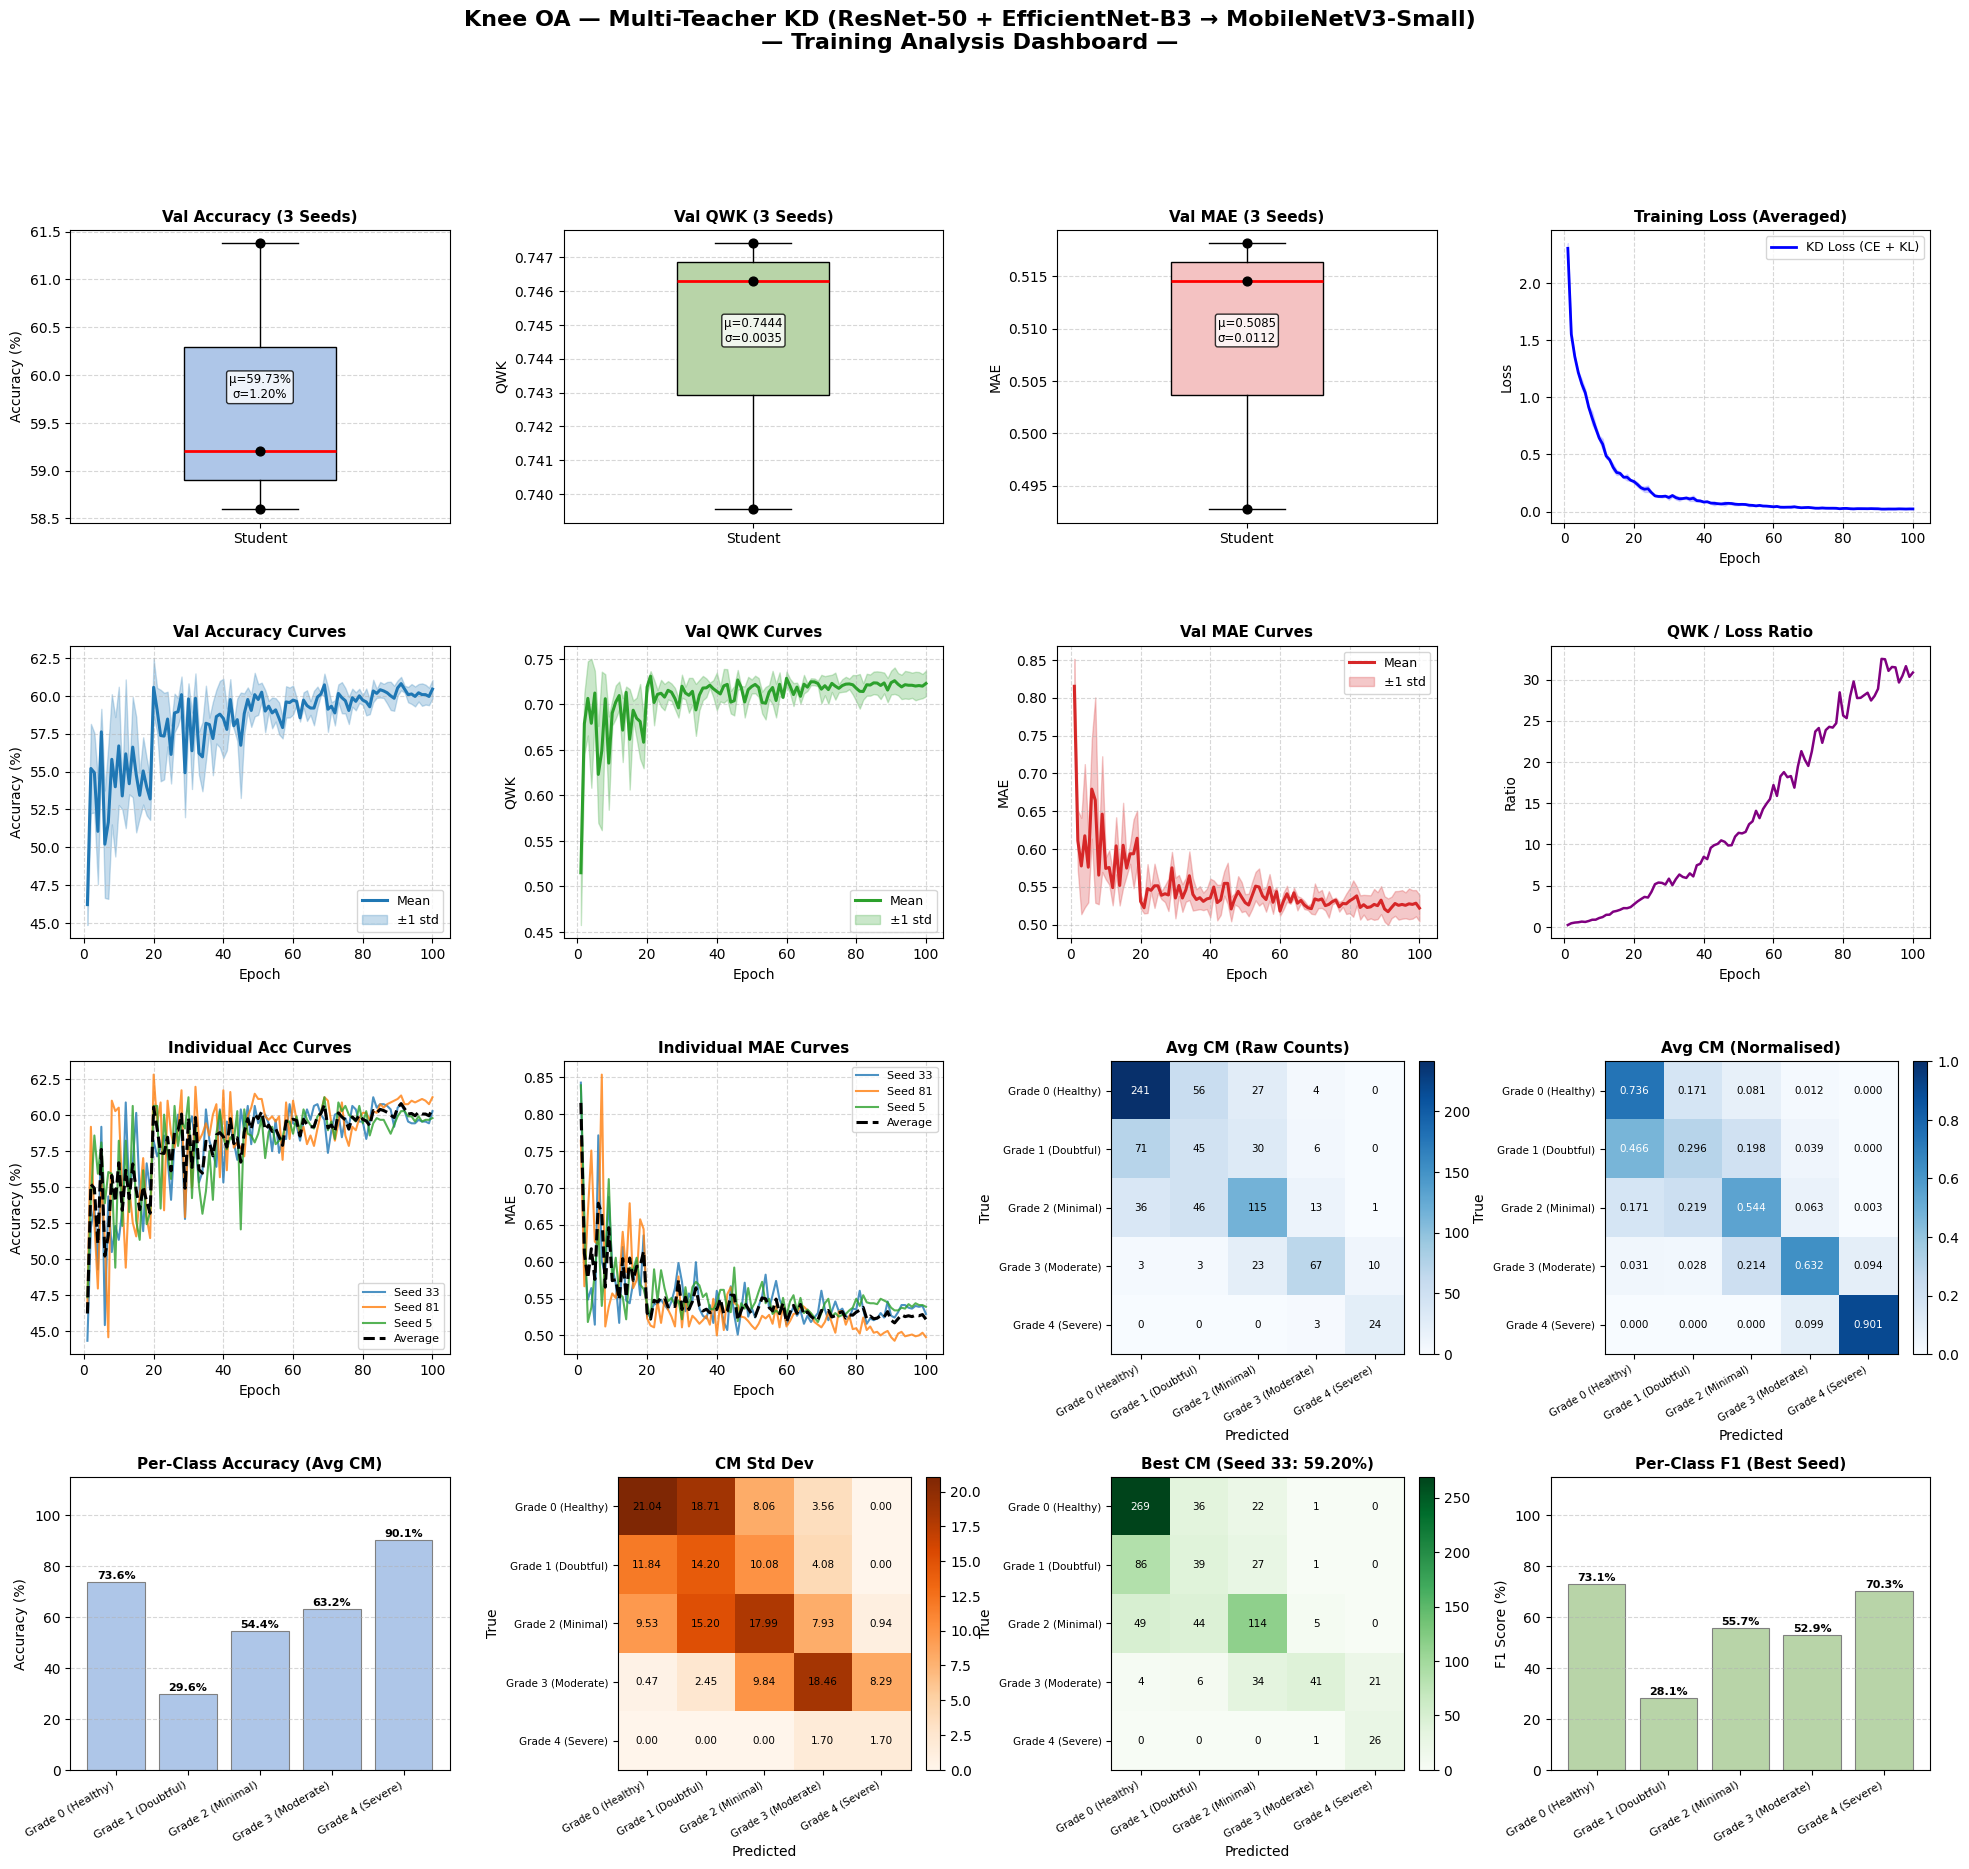

/tmp/ipykernel_58/3209213457.py:296: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout(rect=[0, 0, 1, 0.97])


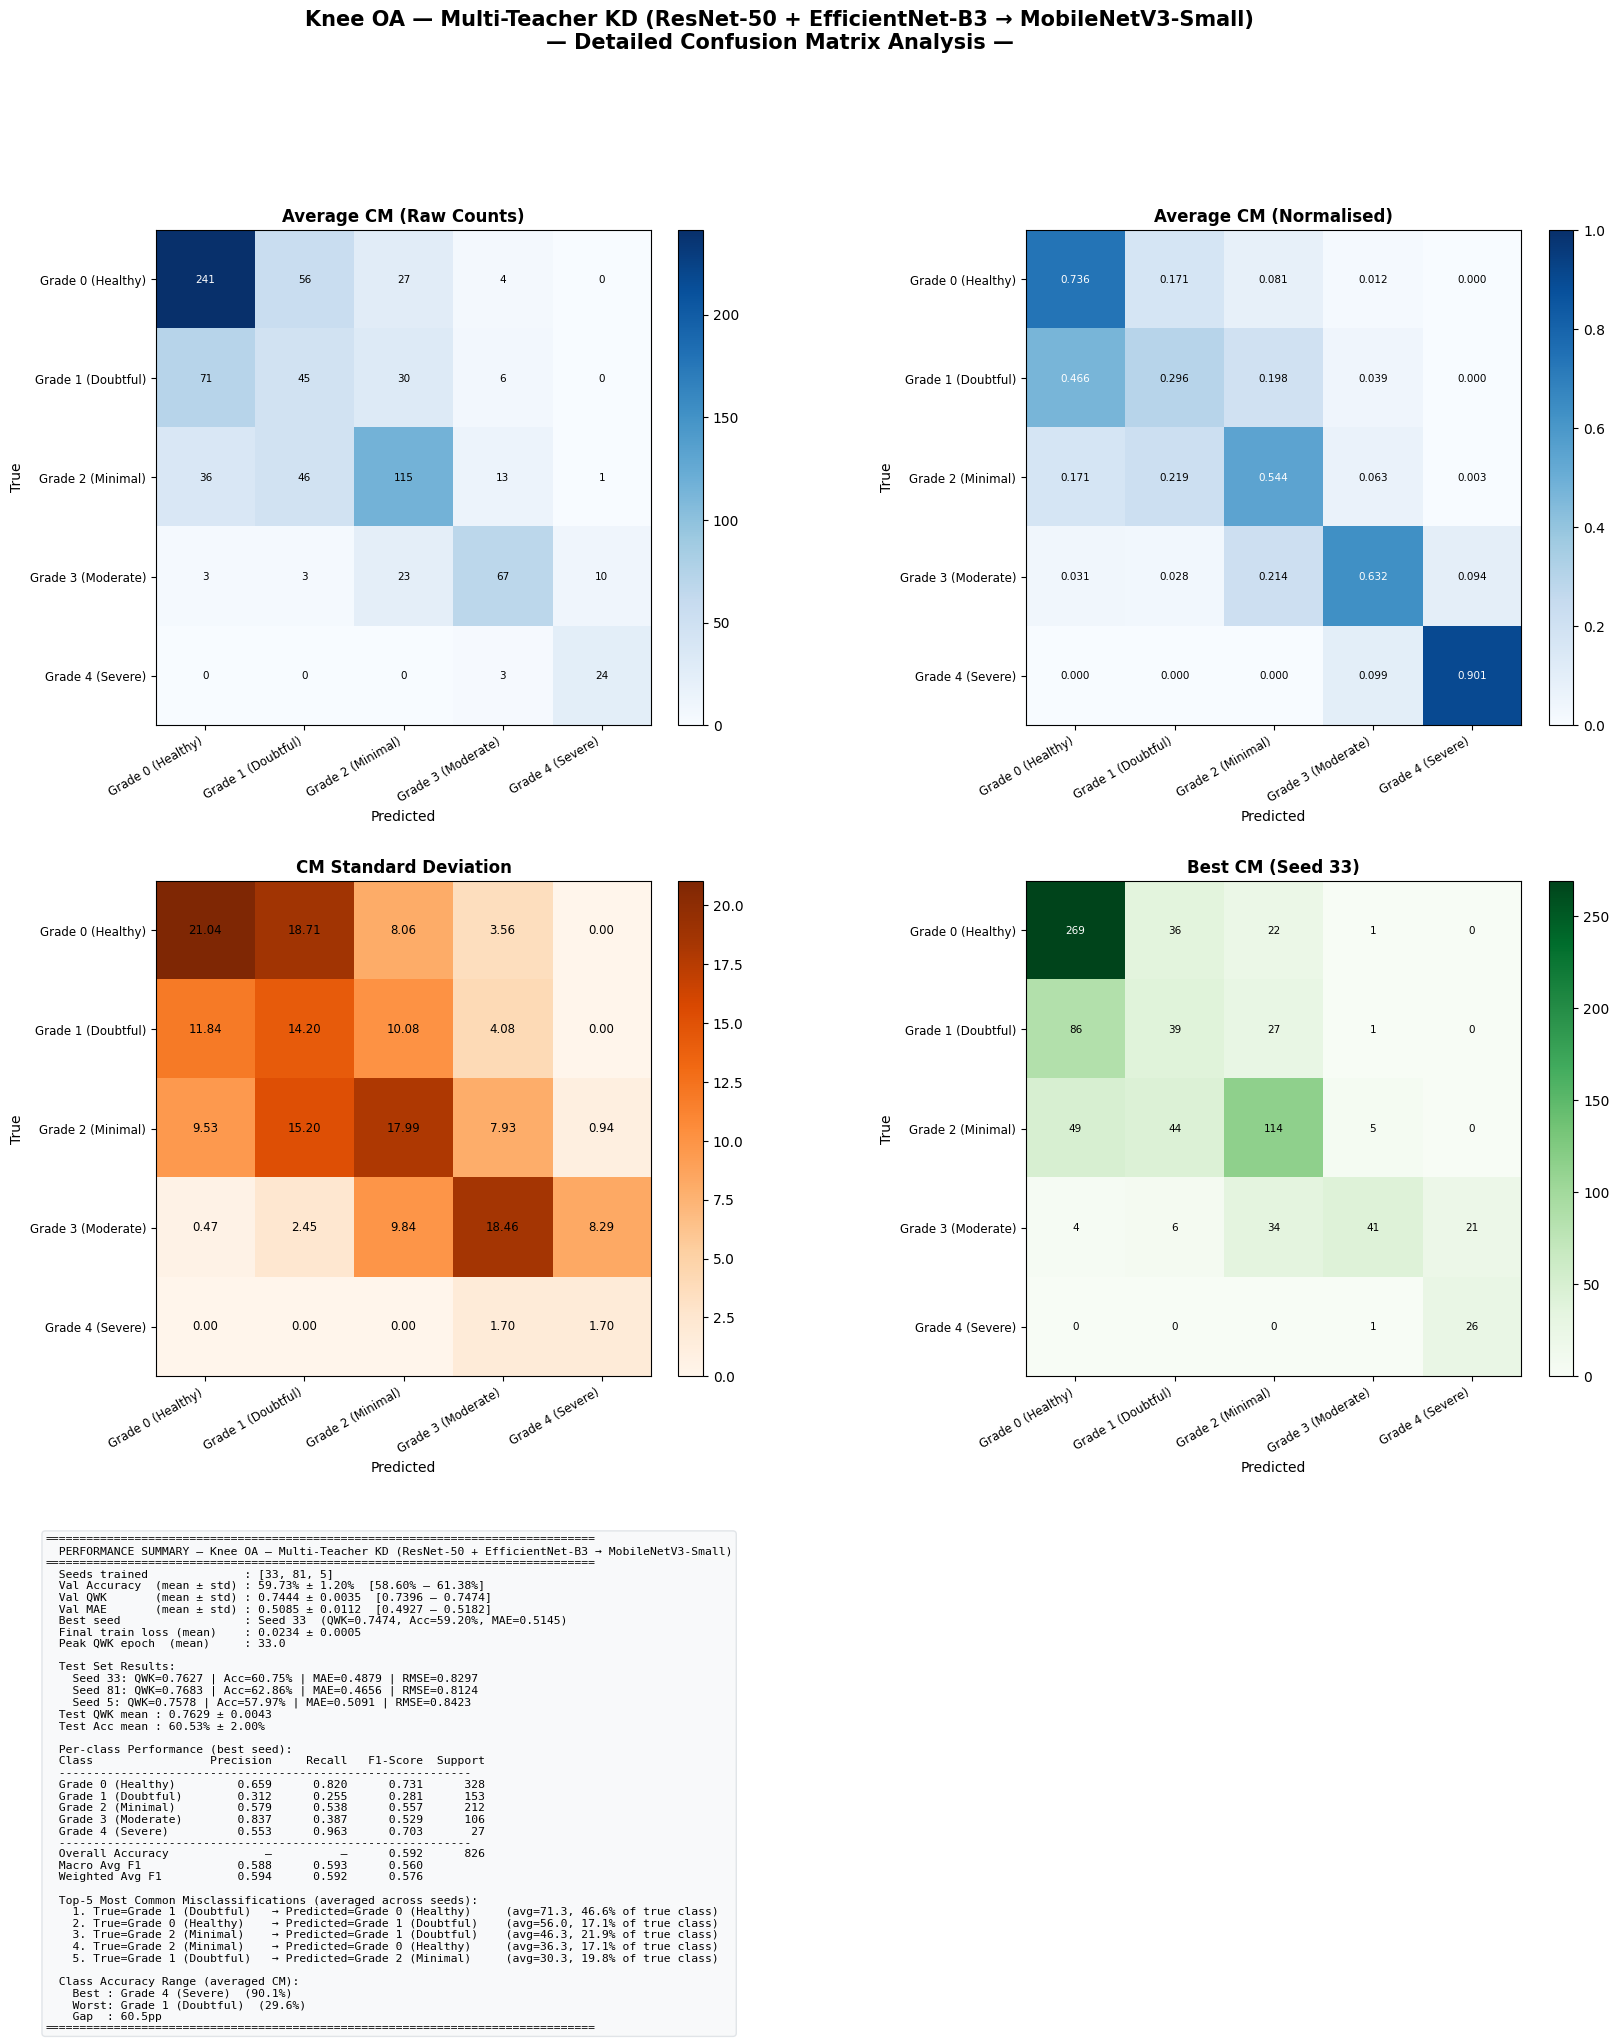

  PERFORMANCE SUMMARY — Knee OA — Multi-Teacher KD (ResNet-50 + EfficientNet-B3 → MobileNetV3-Small)
  Seeds trained              : [33, 81, 5]
  Val Accuracy  (mean ± std) : 59.73% ± 1.20%  [58.60% – 61.38%]
  Val QWK       (mean ± std) : 0.7444 ± 0.0035  [0.7396 – 0.7474]
  Val MAE       (mean ± std) : 0.5085 ± 0.0112  [0.4927 – 0.5182]
  Best seed                  : Seed 33  (QWK=0.7474, Acc=59.20%, MAE=0.5145)
  Final train loss (mean)    : 0.0234 ± 0.0005
  Peak QWK epoch  (mean)     : 33.0

  Test Set Results:
    Seed 33: QWK=0.7627 | Acc=60.75% | MAE=0.4879 | RMSE=0.8297
    Seed 81: QWK=0.7683 | Acc=62.86% | MAE=0.4656 | RMSE=0.8124
    Seed 5: QWK=0.7578 | Acc=57.97% | MAE=0.5091 | RMSE=0.8423
  Test QWK mean : 0.7629 ± 0.0043
  Test Acc mean : 60.53% ± 2.00%

  Per-class Performance (best seed):
  Class                 Precision     Recall   F1-Score  Support
  ------------------------------------------------------------
  Grade 0 (Healthy)         0.659      0.820      0.73

In [16]:
analyse_results(
    results_hybrid,
    "Knee OA — Multi-Teacher KD (ResNet-50 + EfficientNet-B3 → MobileNetV3-Small)",
    loss_label="KD Loss (CE + KL)",
    test_results_list=test_results
)

In [17]:
!pip -q install -U huggingface_hub

from kaggle_secrets import UserSecretsClient
from huggingface_hub import upload_folder
from huggingface_hub import HfApi, create_repo, upload_folder

HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")

create_repo(
    repo_id="almirari/oa-multiteacher-hybrid",
    token=HF_TOKEN,
    exist_ok=True,
)


upload_folder(
    repo_id="almirari/oa-multiteacher-hybrid",
    folder_path="/kaggle/working",
    token=HF_TOKEN
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.1/721.1 kB 13.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 84.0 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


BackendError: Unexpected response from the service. Response: {'errors': ['No user secrets exist for kernel id 125682649 and label HF_TOKEN.'], 'error': {'code': 5}, 'wasSuccessful': False}.